<a href="https://colab.research.google.com/github/rajanani6767/ML/blob/main/TASK8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8172 - loss: 0.5173 - val_accuracy: 0.8413 - val_loss: 0.4325
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8619 - loss: 0.3790 - val_accuracy: 0.8614 - val_loss: 0.3766
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8754 - loss: 0.3369 - val_accuracy: 0.8679 - val_loss: 0.3528
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8837 - loss: 0.3147 - val_accuracy: 0.8802 - val_loss: 0.3319
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8903 - loss: 0.2945 - val_accuracy: 0.8644 - val_loss: 0.3728
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8961 - loss: 0.2780 - val_accuracy: 0.8785 - val_loss: 0.3455
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8995 - loss: 0.2664 - val_accuracy: 0.8832 - val_loss: 0.3309
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9042 - loss: 0.2573 - 

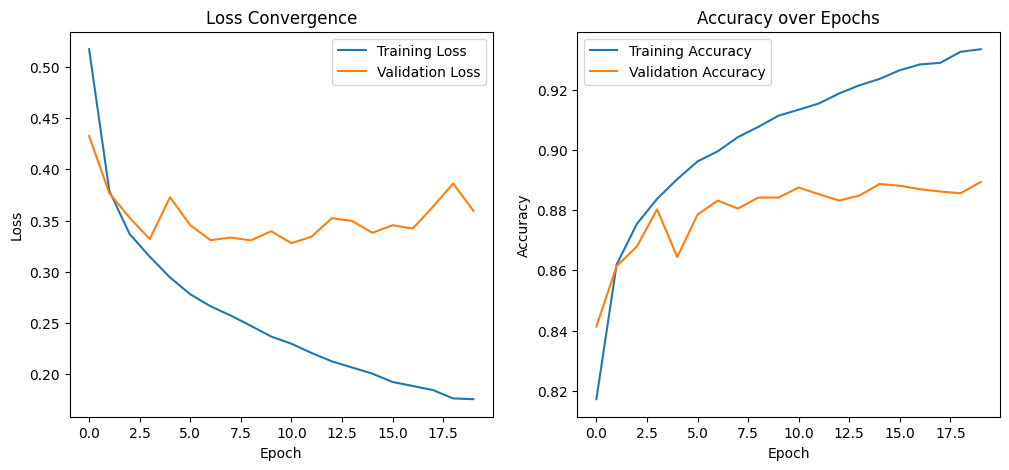

313/313 - 1s - 2ms/step - accuracy: 0.8795 - loss: 0.3870

Test accuracy: 0.8795
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


AttributeError: The layer sequential_3 has never been called and thus has no defined input.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Define the model architecture
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_labels, epochs=20, validation_split=0.2)

# Plot loss and accuracy over epochs
plt.figure(figsize=(12,5))
# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Convergence')
# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

# Initialize the model by passing a sample input
sample_input = test_images[0].reshape(1, 28, 28)
model.predict(sample_input)

# Create a model to output activations of hidden layers
layer_outputs = [layer.output for layer in model.layers[:-1]]  # Exclude output layer
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# Get activations for the sample image
activations = activation_model.predict(sample_input)

# Visualize activations of the first hidden layer
first_layer_activation = activations[0]  # shape: (1, 28, 28, 128)
num_features = first_layer_activation.shape[-1]

plt.figure(figsize=(15, 15))
for i in range(min(16, num_features)):
    plt.subplot(4, 4, i+1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle('Activations of First Hidden Layer')
plt.show()